# Spam Detection: TF-IDF vs Self-Trained Embedding vs Pretrained GloVe

# Importing libraries

In [ ]:
import os
import re
import string
import shutil
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
import kagglehub
import gensim.downloader as gensim_api

RANDOM_STATE = 42

## Retrieve dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("marcelwiechmann/enron-spam-data")
print("Path to dataset files:", path)

Path to dataset files: /Users/annie.boadu/.cache/kagglehub/datasets/marcelwiechmann/enron-spam-data/versions/3


Move data to project path

In [3]:
project_dir = "data/enron-spam-data"

if not os.path.exists(project_dir):
    shutil.copytree(path, project_dir)
    print(f"Copied to {project_dir}")
else:
    print(f"{project_dir} already exists, skipping copy")

data/enron-spam-data already exists, skipping copy


In [4]:
df = pd.read_csv(os.path.join(project_dir, "enron_spam_data.csv")).drop(columns=["Unnamed: 0","Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Subject   33716 non-null  str  
 1   Message   33664 non-null  str  
 2   Spam/Ham  33716 non-null  str  
dtypes: str(3)
memory usage: 790.3 KB


In [5]:
df["Spam/Ham"].value_counts()

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

Data Distribution

<Axes: title={'center': 'Spam vs Ham Distribution'}, xlabel='Spam/Ham'>

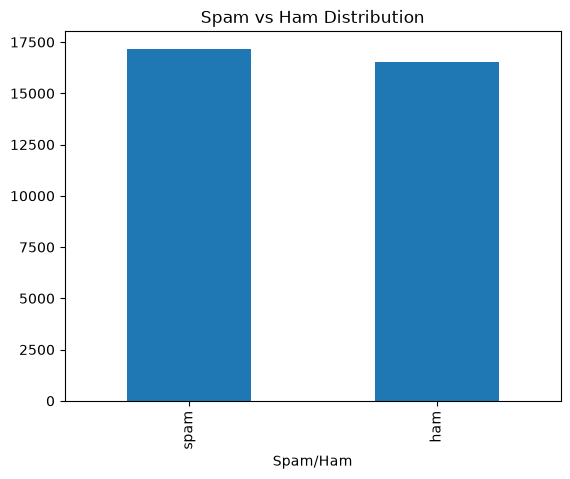

In [6]:
df["Spam/Ham"].value_counts().plot(kind="bar", title="Spam vs Ham Distribution")

## Data Preparation

Combine subject and message into one text for effective handling

In [7]:
df['Subject'] = df['Subject'].fillna('')
df['Message'] = df['Message'].fillna('')
df['text'] = (df['Subject'] + ' ' + df['Message']).str.strip()

In [8]:
df = df[df['text'].str.len() > 0].reset_index(drop=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Subject   33716 non-null  str  
 1   Message   33716 non-null  str  
 2   Spam/Ham  33716 non-null  str  
 3   text      33716 non-null  str  
dtypes: str(4)
memory usage: 1.0 MB


Class remapping

In [10]:
df["label"] = df["Spam/Ham"].map({"ham": 0, "spam": 1})

### Single fixed train/validation/test split

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'], df['label'],
    test_size=0.30, stratify=df['label'], random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

X_train = X_train.reset_index(drop=True); y_train = y_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True);   y_val   = y_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True);  y_test  = y_test.reset_index(drop=True)

len(X_train), len(X_val), len(X_test)

(23601, 5057, 5058)

Confirm stratification held the spam ratio across split

In [12]:
y_train.mean(), y_val.mean(), y_test.mean()

(np.float64(0.5093004533706199),
 np.float64(0.5091951750049436),
 np.float64(0.509292210359826))

### Standardization, tokenization and stopword removal

Creating customised standardizer because the using the default standarization only removes punctuation and coverts to lowercase.

In [ ]:
STOPWORDS = sorted(stopwords.words('english'), key=len, reverse=True)
STOPWORD_PATTERN = r'\b(' + '|'.join(re.escape(w) for w in STOPWORDS) + r')\b'
PUNCT_PATTERN = '[%s]' % re.escape(string.punctuation)

def custom_standardize(input_text):
    lowercase = tf.strings.lower(input_text)
    no_email = tf.strings.regex_replace(lowercase, r'\S+@\S+', ' ')
    no_url = tf.strings.regex_replace(no_email, r'http\S+|www\.\S+', ' ')
    no_punct = tf.strings.regex_replace(no_url, PUNCT_PATTERN, '')
    no_stop = tf.strings.regex_replace(no_punct, STOPWORD_PATTERN, '')
    return tf.strings.regex_replace(no_stop, r'\s+', ' ')

### Vectorization

In [14]:
MAX_TOKENS = 8000
MAX_LEN = int(X_train.str.split().apply(len).quantile(0.95))

# TF-IDF 
tfidf_vectorization = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=custom_standardize,
    output_mode='tf_idf'
)
tfidf_vectorization.adapt(X_train)  # Now let's run our STIE process on the training corpus.


# trainable embedding and pretrained embedding
int_vectorization = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=custom_standardize,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
int_vectorization.adapt(X_train) # Now let's run our STIE process on the training corpus.


MAX_LEN, len(tfidf_vectorization.get_vocabulary()), len(int_vectorization.get_vocabulary())

(1374, 8000, 8000)

In [15]:
X_train_tfidf = tfidf_vectorization(X_train)
X_val_tfidf   = tfidf_vectorization(X_val)
X_test_tfidf  = tfidf_vectorization(X_test)

X_train_seq = int_vectorization(X_train)
X_val_seq   = int_vectorization(X_val)
X_test_seq  = int_vectorization(X_test)

X_train_tfidf.shape, X_train_seq.shape

(TensorShape([23601, 8000]), TensorShape([23601, 1374]))

### Visualize data vocabulary

TF-IDF

In [16]:
tfidf_vectorization.get_vocabulary()[:10]

['[UNK]',
 np.str_('enron'),
 np.str_('e'),
 np.str_('ubs'),
 np.str_('2'),
 np.str_('please'),
 np.str_('subject'),
 np.str_('message'),
 np.str_('ect'),
 np.str_('com')]

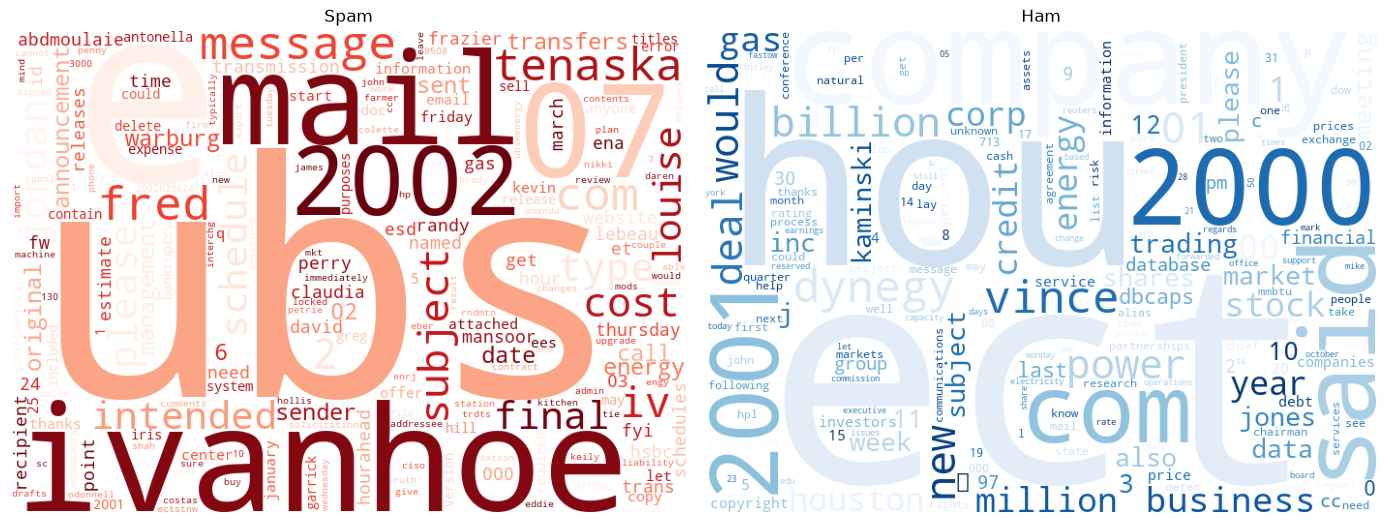

In [17]:
y_train_arr = y_train.values
vocab = tfidf_vectorization.get_vocabulary()

spam_scores = np.array(X_train_tfidf)[y_train_arr == 1].mean(axis=0)
ham_scores  = np.array(X_train_tfidf)[y_train_arr == 0].mean(axis=0)

spam_freq = {vocab[i]: float(spam_scores[i]) for i in range(2, len(vocab)) if spam_scores[i] > 0}
ham_freq  = {vocab[i]: float(ham_scores[i])  for i in range(2, len(vocab)) if ham_scores[i] > 0}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(WordCloud(width=700, height=500, background_color='white', colormap='Reds')
               .generate_from_frequencies(spam_freq))
axes[0].set_title('Spam'); axes[0].axis('off')

axes[1].imshow(WordCloud(width=700, height=500, background_color='white', colormap='Blues')
               .generate_from_frequencies(ham_freq))
axes[1].set_title('Ham'); axes[1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
int_vectorization.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('enron'),
 np.str_('e'),
 np.str_('ubs'),
 np.str_('2'),
 np.str_('please'),
 np.str_('subject'),
 np.str_('message'),
 np.str_('ect')]

By raw frequency

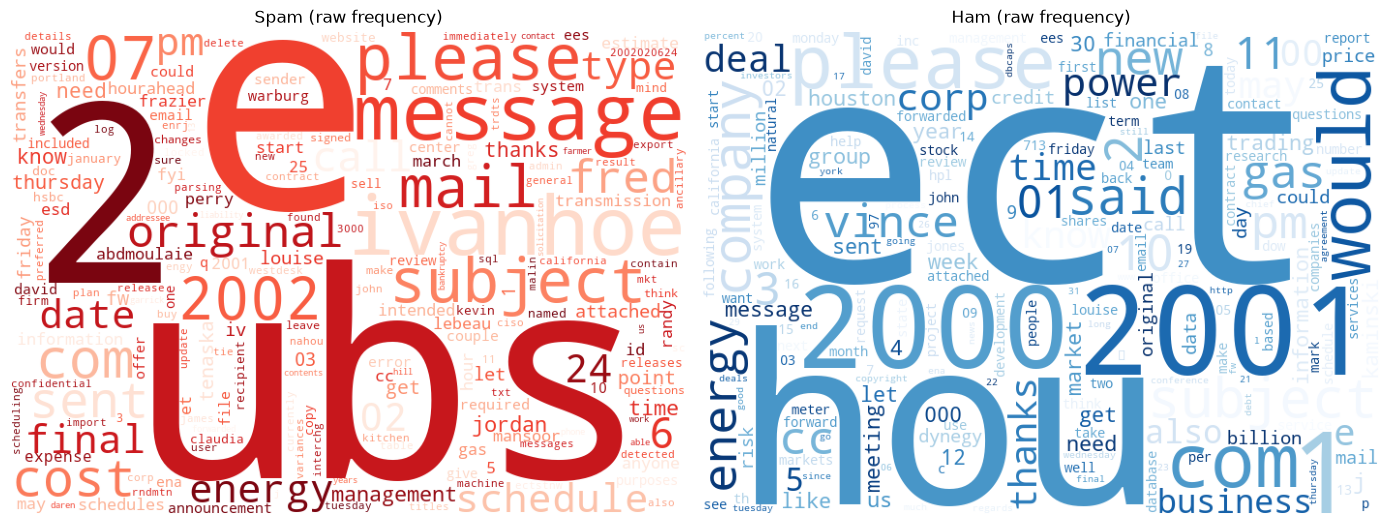

In [19]:
count_vectorization = layers.TextVectorization(
    max_tokens=MAX_TOKENS, standardize=custom_standardize, output_mode='count')
count_vectorization.adapt(X_train)

X_train_counts = count_vectorization(X_train).numpy()
vocab_counts = count_vectorization.get_vocabulary()

spam_counts = X_train_counts[y_train_arr == 1].sum(axis=0)
ham_counts  = X_train_counts[y_train_arr == 0].sum(axis=0)

spam_freq_emb = {vocab_counts[i]: float(spam_counts[i]) for i in range(2, len(vocab_counts)) if spam_counts[i] > 0}
ham_freq_emb  = {vocab_counts[i]: float(ham_counts[i])  for i in range(2, len(vocab_counts)) if ham_counts[i] > 0}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(WordCloud(width=700, height=500, background_color='white', colormap='Reds')
               .generate_from_frequencies(spam_freq_emb))
axes[0].set_title('Spam (raw frequency)'); axes[0].axis('off')

axes[1].imshow(WordCloud(width=700, height=500, background_color='white', colormap='Blues')
               .generate_from_frequencies(ham_freq_emb))
axes[1].set_title('Ham (raw frequency)'); axes[1].axis('off')

plt.tight_layout()
plt.show()
del X_train_counts

## Model Design

### Model 1: TF-IDF + Feedforward NN
**Representation:** TF-IDF, (N, 8000) from tfidf_vectorization.

**Hyperparameters:** Dense(128, relu) -> Dropout(0.5) -> Dense(64, relu) -> Dropout(0.3) -> Dense(1, sigmoid); Adam, lr=1e-3; batch_size=64; small L2 (1e-5) on the first dense layer to counter TF-IDF's high dimensionality relative to dataset size.

**Design Rationale:** TF-IDF already encodes each document as a fixed-length weighted bag-of-words vector meaning there is no sequence order left to us, so a plain feedforward network is the natural and cheapest fit.

In [20]:
def build_tfidf_model(input_dim):
    inp = keras.Input(shape=(input_dim,), name='tfidf_input')
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(inp)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out, name='tfidf_ffn')
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_tfidf = build_tfidf_model(MAX_TOKENS)
model_tfidf.summary()

Model: "tfidf_ffn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tfidf_input (InputLayer)        │ (None, 8000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,024,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,032,449 (3.94 MB)

 Trainable params: 1,032,449 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2: Trainable Embedding + NN
**Representation:** integer sequences from int_vectorization with embedding learned from scratch.

**Hyperparameters:** Embedding(vocab, 100, mask_zero=True) -> GlobalAveragePooling1D -> Dense(64, relu) -> Dropout(0.3) -> Dense(1, sigmoid); Adam, lr=1e-3; batch_size=128.

**Design Rationale:** an embedding trained end-to-end on this corpus can capture Enron/email-domain-specific word associations that a generic pretrained embedding wouldn't have. GlobalAveragePooling1D (rather than an RNN) keeps training fast and is a strong baseline where word presence matters more than order. Given that spam detection often hinges more on which words appear than their exact sequence.

In [21]:
VOCAB_SIZE = int_vectorization.vocabulary_size()
EMBED_DIM = 100

def build_trainable_embedding_model(vocab_size, embed_dim, max_len):
    inp = keras.Input(shape=(max_len,), name='seq_input')
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True, trainable=True)(inp)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out, name='trainable_embedding_nn')
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_trainable = build_trainable_embedding_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model_trainable.summary()

Model: "trainable_embedding_nn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 1374)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1374, 100) │    800,000 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 1374)      │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      6,464 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 806,529 (3.08 MB)

 Trainable params: 806,529 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3: Pretrained Embedding (GloVe) + NN
**Representation:** same integer sequences as Model 2, but the embedding layer is initialized with GloVe (glove-wiki-gigaword-100) vectors and frozen.

**Hyperparameters:** Embedding(vocab, 100, mask_zero=True, trainable=False, initialized from GloVe) -> GlobalAveragePooling1D -> Dense(64, relu) -> Dropout(0.3) -> Dense(1, sigmoid); Adam, lr=1e-3; batch_size=128.

**Design Rationale:** GloVe brings general-purpose semantic structure learned from a huge external corpus, which helps most for words that appear rarely in this training set. Freezing it isolates that effect and avoids overfitting the embedding to a relatively small training set. Architecture is otherwise identical to Model 2 so any performance difference is reflects the embedding source, not the downstream network.

In [22]:
glove = gensim_api.load('glove-wiki-gigaword-100')  # 100d vectors, general-domain corpus

In [23]:
vocab = int_vectorization.get_vocabulary()  # index 0 = padding, index 1 = '[UNK]'
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
hits = 0
for idx, word in enumerate(vocab):
    if word in glove:
        embedding_matrix[idx] = glove[word]
        hits += 1

hits, VOCAB_SIZE, round(hits / VOCAB_SIZE * 100, 1)  # coverage %

(7627, 8000, 95.3)

In [24]:
def build_pretrained_embedding_model(vocab_size, embed_dim, max_len, embedding_matrix, trainable=False):
    inp = keras.Input(shape=(max_len,), name='seq_input')
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True, trainable=trainable,
                          weights=[embedding_matrix])(inp)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out, name='pretrained_embedding_nn')
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_pretrained = build_pretrained_embedding_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN, embedding_matrix)
model_pretrained.summary()

Model: "pretrained_embedding_nn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 1374)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1374, 100) │    800,000 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 1374)      │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding_1[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      6,464 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 806,529 (3.08 MB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 800,000 (3.05 MB)

## Model Training with Callbacks

- **EarlyStopping** on val_loss, restores best weights
- **ModelCheckpoint** saves the best weights per model to disk
- **ReduceLROnPlatea**` halves the learning rate when val_loss stalls

In [25]:
os.makedirs('checkpoints', exist_ok=True)

def make_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f'checkpoints/best_{name}.keras', monitor='val_loss',
                         save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ]

EPOCHS = 12

In [26]:
history_tfidf = model_tfidf.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=EPOCHS, batch_size=64,
    callbacks=make_callbacks('tfidf'), verbose=2
)

Epoch 1/12
369/369 - 2s - 6ms/step - accuracy: 0.9947 - loss: 0.0262 - val_accuracy: 0.9990 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 2/12
369/369 - 1s - 4ms/step - accuracy: 0.9991 - loss: 0.0093 - val_accuracy: 0.9994 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 3/12
369/369 - 1s - 4ms/step - accuracy: 0.9995 - loss: 0.0070 - val_accuracy: 0.9992 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 4/12
369/369 - 2s - 4ms/step - accuracy: 0.9994 - loss: 0.0071 - val_accuracy: 0.9992 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 5/12
369/369 - 1s - 4ms/step - accuracy: 0.9996 - loss: 0.0060 - val_accuracy: 0.9994 - val_loss: 0.0087 - learning_rate: 5.0000e-04


In [27]:
history_trainable = model_trainable.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS, batch_size=128,
    callbacks=make_callbacks('trainable_embedding'), verbose=2
)

Epoch 1/12
185/185 - 6s - 30ms/step - accuracy: 0.9937 - loss: 0.1153 - val_accuracy: 0.9982 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 2/12
185/185 - 5s - 27ms/step - accuracy: 0.9989 - loss: 0.0056 - val_accuracy: 0.9986 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 3/12
185/185 - 5s - 27ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9988 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 4/12
185/185 - 5s - 29ms/step - accuracy: 0.9995 - loss: 0.0031 - val_accuracy: 0.9990 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 5/12
185/185 - 6s - 34ms/step - accuracy: 0.9996 - loss: 0.0031 - val_accuracy: 0.9990 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 6/12
185/185 - 5s - 28ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 0.9990 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 7/12
185/185 - 5s - 28ms/step - accuracy: 0.9996 - loss: 0.0023 - val_accuracy: 0.9992 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 8/12
185/185 - 5s - 29ms/step - accuracy: 

In [28]:
history_pretrained = model_pretrained.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS, batch_size=128,
    callbacks=make_callbacks('pretrained_embedding'), verbose=2
)

Epoch 1/12
185/185 - 2s - 11ms/step - accuracy: 0.8308 - loss: 0.4994 - val_accuracy: 0.9500 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 2/12
185/185 - 1s - 8ms/step - accuracy: 0.9639 - loss: 0.2123 - val_accuracy: 0.9784 - val_loss: 0.1367 - learning_rate: 0.0010
Epoch 3/12
185/185 - 2s - 8ms/step - accuracy: 0.9811 - loss: 0.1121 - val_accuracy: 0.9858 - val_loss: 0.0837 - learning_rate: 0.0010
Epoch 4/12
185/185 - 2s - 8ms/step - accuracy: 0.9858 - loss: 0.0760 - val_accuracy: 0.9885 - val_loss: 0.0608 - learning_rate: 0.0010
Epoch 5/12
185/185 - 2s - 8ms/step - accuracy: 0.9894 - loss: 0.0572 - val_accuracy: 0.9897 - val_loss: 0.0484 - learning_rate: 0.0010
Epoch 6/12
185/185 - 2s - 8ms/step - accuracy: 0.9908 - loss: 0.0460 - val_accuracy: 0.9909 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 7/12
185/185 - 2s - 10ms/step - accuracy: 0.9918 - loss: 0.0389 - val_accuracy: 0.9919 - val_loss: 0.0348 - learning_rate: 0.0010
Epoch 8/12
185/185 - 2s - 9ms/step - accuracy: 0.9932

## Model Evaluation

In [29]:
def evaluate_model(model, X, y, name):
    probs = model.predict(X, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y, preds),
        'precision': precision_score(y, preds),
        'recall': recall_score(y, preds),
        'f1': f1_score(y, preds),
    }

    cm = confusion_matrix(y, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix -- {name}')
    plt.tight_layout()
    plt.show()

    return metrics

def plot_loss_and_acc_curves(history, name, filename):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(loss_values) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, loss_values, "bo", label="Training loss")
    axes[0].plot(epochs, val_loss_values, "b", label="Validation loss")
    axes[0].set_title(f"{name} -- Training and validation loss")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, acc, "bo", label="Training acc")
    axes[1].plot(epochs, val_acc, "b", label="Validation acc")
    axes[1].set_title(f"{name} -- Training and validation accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=110)
    plt.show()

### Model 1: TF-IDF + Feedforward NN

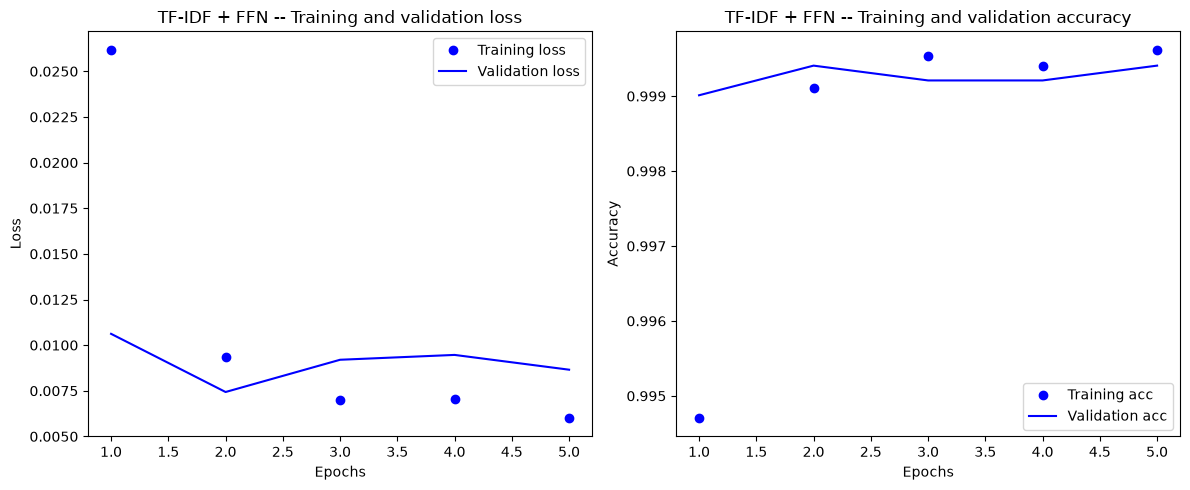

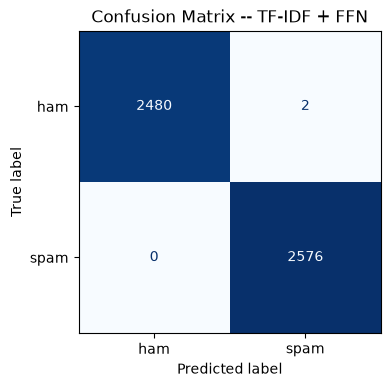

{'model': 'TF-IDF + FFN',
 'accuracy': 0.9996045867931989,
 'precision': 0.9992242048099301,
 'recall': 1.0,
 'f1': 0.9996119518820333}

In [30]:
plot_loss_and_acc_curves(history_tfidf, 'TF-IDF + FFN', 'curves_tfidf.png')
metrics_tfidf = evaluate_model(model_tfidf, X_test_tfidf, y_test, 'TF-IDF + FFN')
metrics_tfidf

### Model 2: Trainable Embedding + NN

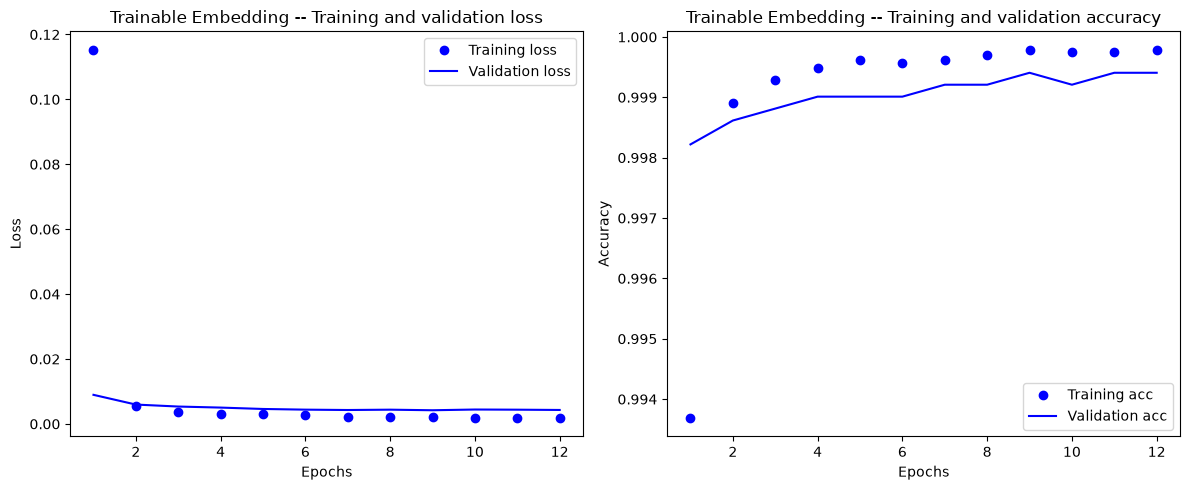

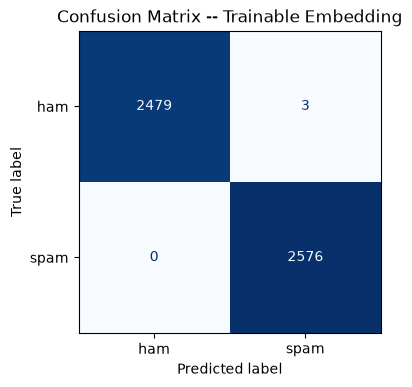

{'model': 'Trainable Embedding',
 'accuracy': 0.9994068801897983,
 'precision': 0.9988367584335014,
 'recall': 1.0,
 'f1': 0.9994180407371483}

In [31]:
plot_loss_and_acc_curves(history_trainable, 'Trainable Embedding', 'curves_trainable.png')
metrics_trainable = evaluate_model(model_trainable, X_test_seq, y_test, 'Trainable Embedding')
metrics_trainable

### Model 3: Pretrained Embedding (GloVe) + NN

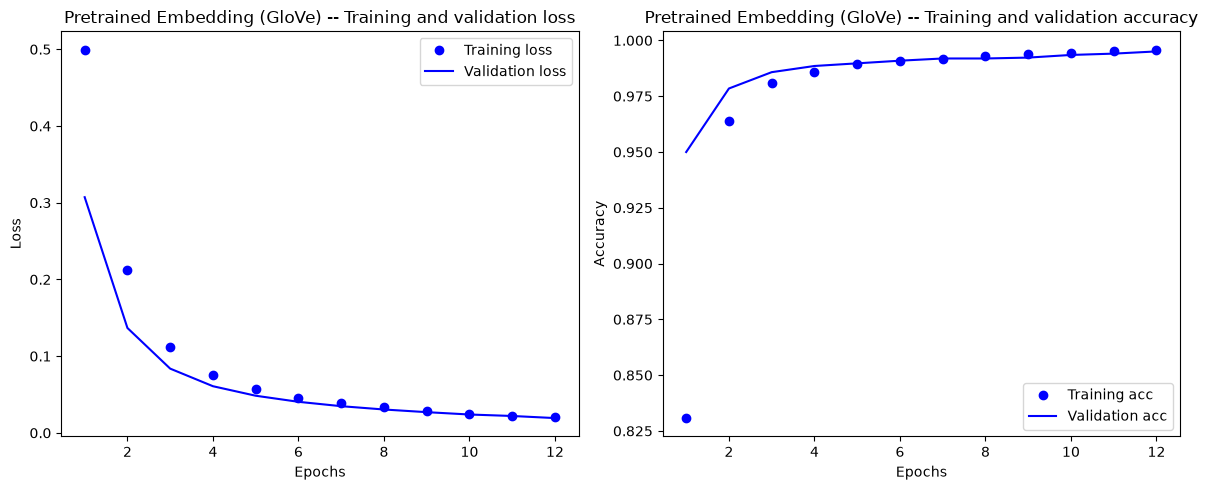

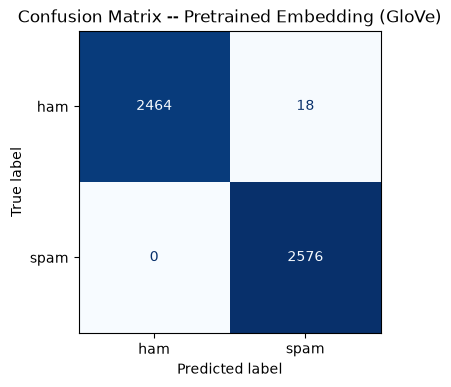

{'model': 'Pretrained Embedding (GloVe)',
 'accuracy': 0.99644128113879,
 'precision': 0.9930609097918273,
 'recall': 1.0,
 'f1': 0.9965183752417794}

In [32]:
plot_loss_and_acc_curves(history_pretrained, 'Pretrained Embedding (GloVe)', 'curves_pretrained.png')
metrics_pretrained = evaluate_model(model_pretrained, X_test_seq, y_test, 'Pretrained Embedding (GloVe)')
metrics_pretrained

### Summary

In [33]:
summary = pd.DataFrame([metrics_tfidf, metrics_trainable, metrics_pretrained]).set_index('model')
summary.round(4)

,accuracy,precision,recall,f1
model,,,,
TF-IDF + FFN,0.9996,0.9992,1.0,0.9996
Trainable Embedding,0.9994,0.9988,1.0,0.9994
Pretrained Embedding (GloVe),0.9964,0.9931,1.0,0.9965


## Fine-Tuned Pretrained Model (supplementary -- not part of the required 3-way comparison)

Section 3 requires exactly one pretrained-embedding model; Model 3 above uses it frozen (`trainable=False`). As a supplementary check, we test whether unfreezing it (`trainable=True`) and letting backprop adjust the pretrained vectors narrows the gap to TF-IDF/self-trained. This does not replace Model 3 in the main comparison table.

In [34]:
model_pretrained_ft = build_pretrained_embedding_model(
    VOCAB_SIZE, EMBED_DIM, MAX_LEN, embedding_matrix, trainable=True)
model_pretrained_ft.summary()

Model: "pretrained_embedding_nn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 1374)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1374, 100) │    800,000 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 1374)      │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding_2[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      6,464 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 806,529 (3.08 MB)

 Trainable params: 806,529 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_pretrained_ft = model_pretrained_ft.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS, batch_size=128,
    callbacks=make_callbacks('pretrained_finetuned'), verbose=2
)


Epoch 1/12
185/185 - 6s - 30ms/step - accuracy: 0.9644 - loss: 0.1380 - val_accuracy: 0.9976 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 2/12
185/185 - 5s - 27ms/step - accuracy: 0.9987 - loss: 0.0070 - val_accuracy: 0.9986 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 3/12
185/185 - 5s - 26ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9986 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 4/12
185/185 - 5s - 30ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9988 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 5/12
185/185 - 5s - 29ms/step - accuracy: 0.9995 - loss: 0.0031 - val_accuracy: 0.9990 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 6/12
185/185 - 5s - 28ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 0.9990 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 7/12
185/185 - 5s - 28ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 0.9990 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 8/12
185/185 - 5s - 28ms/step - accuracy: 

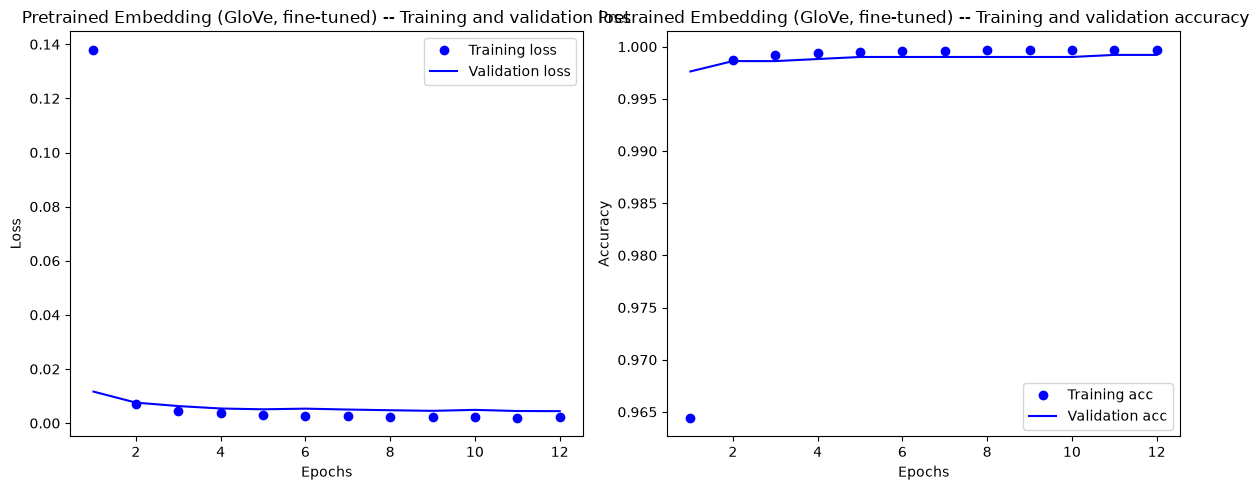

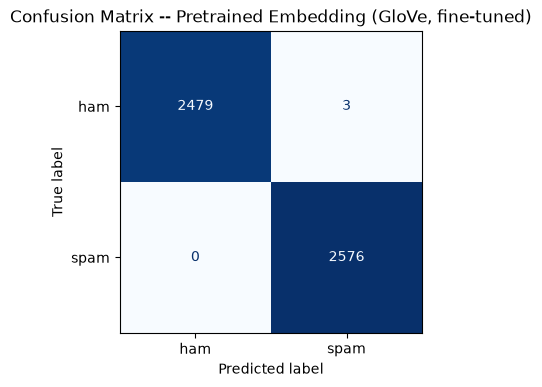

,accuracy,precision,recall,f1
model,,,,
Pretrained Embedding (GloVe),0.9964,0.9931,1.0,0.9965
"Pretrained Embedding (GloVe, fine-tuned)",0.9994,0.9988,1.0,0.9994


In [36]:
plot_loss_and_acc_curves(history_pretrained_ft, 'Pretrained Embedding (GloVe, fine-tuned)', 'curves_pretrained_ft.png')
metrics_pretrained_ft = evaluate_model(model_pretrained_ft, X_test_seq, y_test,
                                       'Pretrained Embedding (GloVe, fine-tuned)')

finetune_comparison = pd.DataFrame([metrics_pretrained, metrics_pretrained_ft]).set_index('model')
finetune_comparison.round(4)

##  Evaluation on Unseen External Data

Using the UCI SMS Spam Collection as the external test set

In [37]:
models = {
    'TF-IDF + FFN': (model_tfidf, tfidf_vectorization),
    'Self-trained Embedding': (model_trainable, int_vectorization),
    'Pretrained Embedding (GloVe)': (model_pretrained, int_vectorization),
}

In [38]:
import urllib.request, zipfile, io

sms_url = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'
resp = urllib.request.urlopen(sms_url, timeout=30)
z = zipfile.ZipFile(io.BytesIO(resp.read()))
with z.open('SMSSpamCollection') as f:
    sms = pd.read_csv(f, sep='\t', header=None, names=['label', 'text'])
sms['y'] = sms['label'].map({'ham': 0, 'spam': 1})
len(sms), sms['y'].mean()

(5572, np.float64(0.13406317300789664))

/Users/annie.boadu/Desktop/docs/Academic city/Deep Learning & Neural Networks/Exam/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


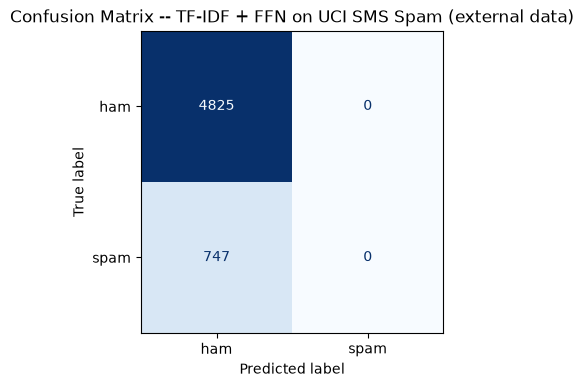

{'model': 'TF-IDF + FFN on UCI SMS Spam (external data)',
 'accuracy': 0.8659368269921034,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0}

In [39]:
best_name = summary['f1'].idxmax()
best_model, vectorizer = models[best_name]

X_ext = vectorizer(sms['text'])
external_metrics = evaluate_model(best_model, X_ext, sms['y'], f'{best_name} on UCI SMS Spam (external data)')
external_metrics

**Result:** despite an accuracy around 87% (the SMS dataset has around 87% ham instances), precision and recall on the spam class are both 0%, the model predicts "ham" for every message. In-domain accuracy on Enron does not transfer to a different text genre.

### Interactive message classifier

In [40]:
def classify_message(text):
    for name, (model, vectorizer) in models.items():
        vect_data = vectorizer([text])
        prob = model.predict(vect_data, verbose=0)[0][0]
        label = 'spam' if prob >= 0.5 else 'ham'
        print(f"{name:32s}  {prob*100:6.2f}% spam  ->  {label}")

In [41]:
classify_message("URGENT: You've won a free prize, click here to claim now!!!")

TF-IDF + FFN                        0.67% spam  ->  ham
Self-trained Embedding              0.00% spam  ->  ham
Pretrained Embedding (GloVe)        0.00% spam  ->  ham
